# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [183]:
import numpy as np
import matplotlib.pyplot as plt

# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijk apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen veld maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!

## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\
c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

<img src="Opdracht 1 a).jpg" width="400">
<img src="Opdracht 1 b).jpg" width="400">
<img src="Opdracht 1 c).jpg" width="400">

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

<img src="Opdracht 2.jpg" width="400">

Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

<img src="Opdracht 3.jpg" width="400">

## Deel 2: Criteria opstellen

Jullie gaan nu een magnetische kracht actuator ontwerpen hiervoor gaan jullie nu een ontwerpcyclus doorlopen.

**Opdracht 4**

a. Bedenk en schets vijf toepassingen van een kracht actuator.\
b. Kies uit deze toepassingen minimaal 2 toepassingen voor een kracht actuator om verder mee door te rekenen.

Plaats hier een foto van jullie vijf schetsen met uitleg over wat er te zien is.

<img src="ActuatorDeur.jpg" width="400">
<img src="4andere.jpg" width="400">

In beide foto's zijn verschillende toepassingen van een krachtactuator te zien. De eerste is een automatische deur, die open-/dichtgaat als de sensor boven de deur beweging waarneemt. De actuator speelt dan de rol van het verschuiven van de deur. Zo ook bij de slagboom, de sensor meet of er een auto voor de slagboom staat, en de actuator doet de slagboom open. Bij de waterkraan zorgt de actuator dat de waterklep opengaat zodat er water uit de kraan kan stromen. En bij de automatische autoramen zorgt de actuator ervoor dat de ramen opengaan als er op een knop gedrukt wordt. Als laatste het verstelbare bureau, wat omhoog en omlaag kan bewegen door de actuator als er op een knop gedrukt wordt.

**Opdracht 5**

We gaan nu verder kijken naar de criteria van jullie kracht actuatoren. Wij hebben alvast twee essentiele criteria vastgesteld zodat we hier later in de opdracht mee verder kunnen rekenen. Hieronder zijn 4 veelgebruikte stroombronnen benoemd die jullie gaan gebruiken voor een van de criteria.

| Spanningsbron             | Stroomsterkte | Voltage | draad dikte van de spoel |
|:--------------------------|:--------------|:--------|:-------------------------|
| Arduino uno digital pin   | 40 mA         | 5 V     | 0.05 mm                  |
| 9 Volt batterij           | 500 mA        | 9 V     | 0.1  mm                  |
| 40 Watt telefoon oplader | 2 A           | 20 V    | 0.2 mm                   |
| Een auto batterij         | 180 A         | 12 V    | 1.5 mm                   |


a. Kies een van de hierboven benoemde stroombronnen om te gebruiken in jullie ontwerp. \
b. Gebruik de methode uit het college 'schattend rekenen' om voor elke toepassing de minimale kracht die de actuator moet kunnen leveren voor jullie toepassing te bepalen.\
c. Denk na over wat de straal van jullie actuator mag zijn. \
d. Bedenk nog 1 ander criterium per toepassing.

Plaats hier een foto van jullie uitwerkingen op vraag 5.
<img src="Opdracht 5.jpg" width="400">

## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

Jullie zullen nu simulaties gaan uitvoeren om de grenzen van jullie ontwerpparameters op te zoeken. Dit doen jullie voor jullie twee gekozen toepassingen en een deuractuator. Deze deuractuator moet een deur van het slot afhaalen door een kracht van 40 N uit te oefenen, gebruikt een 9 volt batterij als stroombron, de plunjer is gemaakt van ijzer en de straal van de actuator is 0.01 m.

**Opdracht 6**

Zet de relevante parameters in een Python script en maak een Python functie die met behulp van de wet van Ohm de maximale draadlengte uitrekent. Print de maximale draadlengte bij het uitvoeren van het script.

In [184]:
### Constantes:
mu_0 = 4*np.pi*1e-7 # N/(A**2)

### Parameters:
## Schema: Naamgeving
# Variabel_Naam_[Toepassing]_[Iteratie]
# -> Autoraam           : 1
# -> Verstelbaar bureau : 2
# -> Deuractuator       : 3 

## Autoraam
V_bron_1 = 9 #V
I_bron_1 = 500e-3 #A
F_min_1 = 50 #N
Soortelijke_R_draad_1_1 = 1.68e-8 #Ohm*m
mu_r_plunjer_1_1 = 50000
Straal_spoel_1_1 = 0.008 #m
Straal_draad_1_1 = 0.05e-3 #m


## Verstelbaar bureau
V_bron_2 = 20 #V -> Batterij als spanningsbron is niet voldoende
I_bron_2 = 2 #A
F_min_2 = 300 #N
Soortelijke_R_draad_2_1 = 1.68e-8 #Ohm*m
mu_r_plunjer_2_1 = 50000
Straal_spoel_2_1 = 0.01 #m
Straal_draad_2_1 = 0.1e-3 #m


## Deuractuator
V_bron_3 = 9 #V
I_bron_3 = 500e-3 #A
F_min_3 = 40 #N
Soortelijke_R_draad_3_1 = 1.68e-8 #Ohm*m
mu_r_plunjer_3_1 = 50000
Straal_spoel_3_1 = 0.01 #m
Straal_draad_3_1 = 0.05e-3 #m


### Analytische Functies

# Lengte van de Draad
def Lengte_draad(V_bron, I, Soortelijke_R_draad, Straal_draad):
    L = (V_bron*np.pi*Straal_draad**2)/(I*Soortelijke_R_draad)
    return L


# Kracht die op de Plunjer uitgeoefend wordt
def F_plunjer(N_wendinge_spoel, Straal_spoel, Lengte_spoel, mu_r_plunjer, I_spoel):
    F = (mu_0*np.pi*(mu_r_plunjer-1)*(Straal_spoel*N_wendinge_spoel*I_spoel)**2)/(2*Lengte_spoel**2)
    return F

In [185]:
### Berkenen van de lengte van de draad mbv formule hierboven

Max_lengte_draad_1_1 = Lengte_draad(V_bron_1, I_bron_1, Soortelijke_R_draad_1_1, Straal_draad_1_1)
Max_lengte_draad_2_1 = Lengte_draad(V_bron_2, I_bron_2, Soortelijke_R_draad_2_1, Straal_draad_2_1)
Max_lengte_draad_3_1 = Lengte_draad(V_bron_3, I_bron_3, Soortelijke_R_draad_3_1, Straal_draad_3_1)


print("De maximale lengte van de draad bij toepassing 1 is: ", round(Max_lengte_draad_1_1,2), "m")
print("De maximale lengte van de draad bij toepassing 2 is: ", round(Max_lengte_draad_2_1,2), "m")
print("De maximale lengte van de draad bij toepassing 3 is: ", round(Max_lengte_draad_3_1,2), "m")

# -> Autoraam           : toepassing 1
# -> Verstelbaar bureau : toepassing 2
# -> Deuractuator       : toepassing 3 

# Twee belangerijke formules voor de parameters hieronder:
#Lengte_draad ~= 2*np.pi*Straal_spoel*N_wendinge_spoel
#Lengte_spoel ~= 2*Straal_draad*N_wendinge_spoel


De maximale lengte van de draad bij toepassing 1 is:  8.41 m
De maximale lengte van de draad bij toepassing 2 is:  18.7 m
De maximale lengte van de draad bij toepassing 3 is:  8.41 m


**Opdracht 7**

Leidt een vergelijking af voor het minimale aantal wikkelingen $N$ die je nodig hebt om het gewicht op te kunnen tillen. Voeg je afleiding als png toe aan je notebook.

<img src="Opdracht 6 7.jpg" width="400">

We gaan nu de ontwerpvrijheid verkennen. Gegeven de materiaalparameters en de eigenschappen van de stroombron kunnen we de verhouding tussen de lengte en de straal van de solenoide kiezen.

**Opdracht 8**

Schrijf een enkele Python functie die het minimum en maximum aantal wikkelingen uitrekent als functie van $L_s$, $r_s$, $r_d$ en $I$. De functie moet de volgende voorwaarden controleren
1) Het minimum aantal wikkelingen wordt gegeven door de hiervoor afgeleide relatie van het aantal wikkelingen om de benodigde kracht te genereren. 
2) Het maximum aantal wikkelingen wordt gegeven door de draaddikte $r_d$ en de lengte $L_s$
3) Het maximum aantal wikkelingen wordt gegeven door de draadlengte en de straal van de solenoide
4) Het maximum aantal wikkelingen moet groter zijn dan het minimum aantal wikkelingen

Het maximum aantal wikkelingen is de kleinste van voorwaarde 2) en 3). Geef een foutmelding als het minimum aantal windingen groter is dan het maximum aantal windingen.

Plaats hier een png met jullie eventuele analytische afleiding.

In [186]:
### BEGIN SOLUTION

def aantal_wikkelingen(V_bron, I, Straal_draad, Soortelijke_R_draad, Straal_spoel, Lengte_spoel, mu_r_plunjer, F_min):
    # Voeg hieronder de formules voor het maximum en minimum aantal wikkelingen.
    N_min = (Lengte_spoel/(I*Straal_spoel))*np.sqrt((2*F_min)/(mu_0*(mu_r_plunjer-1)*np.pi))
    N_max_2 = (V_bron*Straal_draad**2)/(2*Soortelijke_R_draad*Straal_spoel*I) 
    N_max_1 = Lengte_spoel/(2*Straal_draad)

    N_max = min(N_max_1, N_max_2)

    if N_min > N_max: ## Als het ontwerp niet mogelijk is.
        print('The design with %.1f unit has no workable solution'%a)
        N_min = 'NaN'
        N_max = 'NaN'
    N_max = max(N_max_1,N_max_2)
    return N_min, N_max



## functie toegepast om array te verwerken
def aantal_wikkelingen_array(V_bron, I_bron, Straal_draad, Soortelijke_R_draad, Straal_spoel, Lengte_spoel, mu_r_plunjer, F_min):
    # Voeg hieronder de formules voor het maximum en minimum aantal wikkelingen.
    N_min_array = np.zeros(len(Lengte_spoel))
    N_max_array = np.zeros(len(Lengte_spoel))
    N_max_1_array = np.zeros(len(Lengte_spoel))
    N_max_2_array = np.zeros(len(Lengte_spoel))
    
    for l in range(len(Lengte_spoel)):
        Lengte_spoel_l = Lengte_spoel[l]
        N_min = (Lengte_spoel_l/(I_bron*Straal_spoel))*np.sqrt((2*F_min)/(mu_0*(mu_r_plunjer-1)*np.pi))
        N_max_1 = Lengte_spoel_l/(2*Straal_draad)
        N_max_2 = (V_bron*Straal_draad**2)/(2*Soortelijke_R_draad*Straal_spoel*I_bron) 
        N_max = min(N_max_1, N_max_2)

        N_max_1_array[l] = N_max_1
        N_max_2_array[l] = N_max_2


        if N_min > N_max: ## Als het ontwerp niet mogelijk is.
            print('The design with %.2f m has no workable solution' %Lengte_spoel_l)
            N_min = 'NaN'
            N_max = 'NaN'

        N_min_array[l] = N_min
        N_max_array[l] = N_max


    return N_min_array, N_max_array, N_max_1_array, N_max_2_array
    

Een parameter plot geeft ons inzicht in de haalbaarheid van het idee. In dit geval willen we kijken naar het mogelijke aantal wikkelingen en de lengte van onze solenoide. Hieronder staat een voorbeeld van code die een voorbeeld plot creëert met minimale eis $y=x$ en de maximale eis $y=2x$.

Text(0, 0.5, 'y')

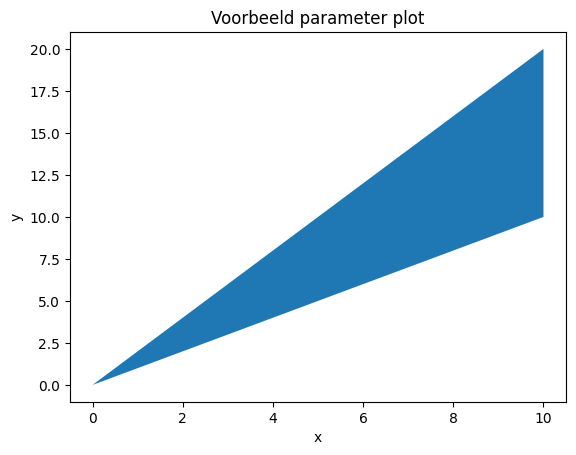

In [187]:
x = np.linspace(0,10,100)
y_min = x # Minimale eis
y_max = 2*x # Maximale eis

plt.fill_between(x,y_min,y_max) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")


**Opdracht 9**

Maak een parameterplot met behulp van bovenstaand gedefinieerde functie voor de drie solenoideactuatoren voor $L_s$ tussen 0 en 1 m in 50 stappen. Een parameter plot ziet er hier uit als een plot tussen het minimale aantal wikkelingen en het maximaal aantal wikkelingen.



The design with 0.04 m has no workable solution
The design with 0.06 m has no workable solution
The design with 0.08 m has no workable solution
The design with 0.10 m has no workable solution
The design with 0.12 m has no workable solution
The design with 0.14 m has no workable solution
The design with 0.16 m has no workable solution
The design with 0.18 m has no workable solution
The design with 0.20 m has no workable solution
The design with 0.22 m has no workable solution
The design with 0.24 m has no workable solution
The design with 0.27 m has no workable solution
The design with 0.29 m has no workable solution
The design with 0.31 m has no workable solution
The design with 0.33 m has no workable solution
The design with 0.35 m has no workable solution
The design with 0.37 m has no workable solution
The design with 0.39 m has no workable solution
The design with 0.41 m has no workable solution
The design with 0.43 m has no workable solution
The design with 0.45 m has no workable s

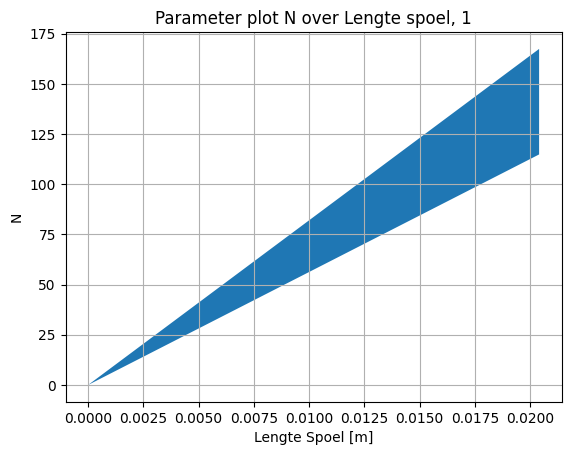

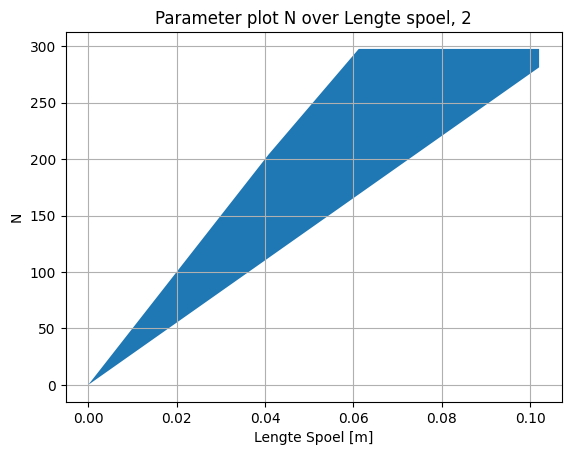

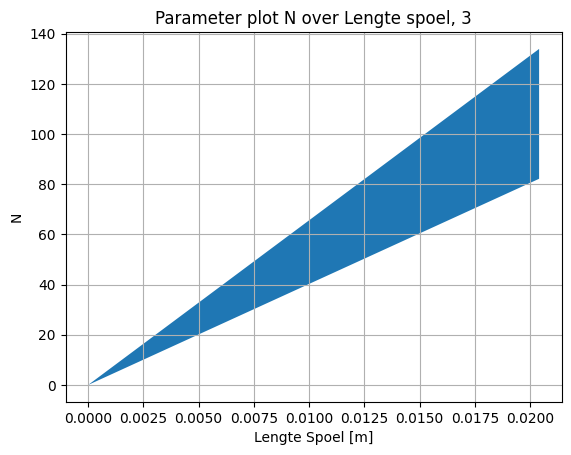

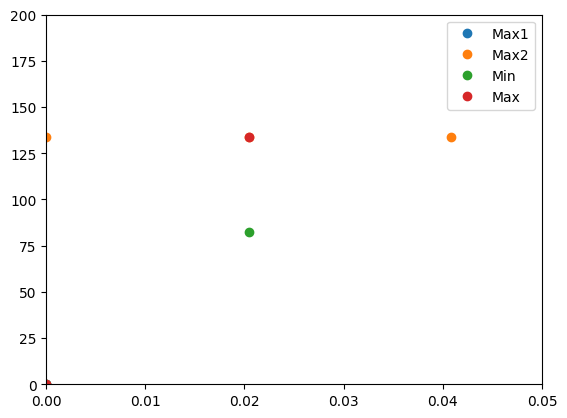

167.41071428571425
297.6190476190476
133.92857142857142


In [188]:
### Parameterplot
Lengte_spoel_array = np.linspace(0,1,50) #m
N_wendinge_spoel_min_1, N_wendinge_spoel_max_1, N_wendinge_spoel_max1_1, N_wendinge_spoel_max2_1 = aantal_wikkelingen_array(V_bron_1, I_bron_1, Straal_draad_1_1, Soortelijke_R_draad_1_1, Straal_spoel_1_1, Lengte_spoel_array, mu_r_plunjer_1_1, F_min_1)
N_wendinge_spoel_min_2, N_wendinge_spoel_max_2, N_wendinge_spoel_max1_2, N_wendinge_spoel_max2_2 = aantal_wikkelingen_array(V_bron_2, I_bron_2, Straal_draad_2_1, Soortelijke_R_draad_2_1, Straal_spoel_2_1, Lengte_spoel_array, mu_r_plunjer_2_1, F_min_2)
N_wendinge_spoel_min_3, N_wendinge_spoel_max_3, N_wendinge_spoel_max1_3, N_wendinge_spoel_max2_3 = aantal_wikkelingen_array(V_bron_3, I_bron_3, Straal_draad_3_1, Soortelijke_R_draad_3_1, Straal_spoel_3_1, Lengte_spoel_array, mu_r_plunjer_3_1, F_min_3)


plt.figure()
plt.fill_between(Lengte_spoel_array, N_wendinge_spoel_min_1, N_wendinge_spoel_max_1) # De ruimte tussen de eisen vullen
plt.title("Parameter plot N over Lengte spoel, 1")
plt.xlabel("Lengte Spoel [m]")
plt.ylabel("N")
plt.grid()
plt.show()

plt.figure()
plt.fill_between(Lengte_spoel_array, N_wendinge_spoel_min_2, N_wendinge_spoel_max_2) # De ruimte tussen de eisen vullen
plt.title("Parameter plot N over Lengte spoel, 2")
plt.xlabel("Lengte Spoel [m]")
plt.ylabel("N")
plt.grid()
plt.show()

plt.figure()
plt.fill_between(Lengte_spoel_array, N_wendinge_spoel_min_3, N_wendinge_spoel_max_3) # De ruimte tussen de eisen vullen
plt.title("Parameter plot N over Lengte spoel, 3")
plt.xlabel("Lengte Spoel [m]")
plt.ylabel("N")
plt.grid()
plt.show()



plt.figure()
plt.plot(Lengte_spoel_array, N_wendinge_spoel_max1_3, 'o', label="Max1")
plt.plot(Lengte_spoel_array, N_wendinge_spoel_max2_3, 'o', label="Max2")
plt.plot(Lengte_spoel_array, N_wendinge_spoel_min_3, 'o', label="Min")
plt.plot(Lengte_spoel_array, N_wendinge_spoel_max_3, 'o', label="Max")
plt.legend()
plt.xlim(0,0.05)
plt.ylim(0,200)
plt.show()
print(N_wendinge_spoel_max2_1[1])
print(N_wendinge_spoel_max2_2[1])
print(N_wendinge_spoel_max2_3[1])

**Opdracht 10**

Maak voor elke actuator een keuze voor de lengte van de spoel, de straal van de spoel en de lengte van de draad.

1: Autoraam: N = 167, L_spoel = 0.021 m

2: Bureautafel: N = 297, L_spoel = 0.06 m

3: Deur : N = 133, L_spoel = 0.021 m

In [189]:
Lengte_spoel_1 = 0.021 #m
Lengte_spoel_2 = 0.06 #m
Lengte_spoel_3 = 0.021 #m

Bovenstaande analytische berekening is een goede start voor het ontwerp en geeft aan welke parameters je kan optimaliseren. Echter in een echte solenoide zullen er allerlei niet ideale effecten een rol spelen. Zo zal het veld in de solenoide niet constant zijn (het is geen oneindig lange solenoide) en zijn er randvelden aan de uiteinden van de solenoide. We zullen nu de kracht-afstand relatie van de solenoide krachtactuator uitrekenen. Deze kan dan verder geoptimaliseerd worden om de kracht-uitwijking relatie zo lineair mogelijk te maken.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

<img align="right" style="margin-left:15px" src="wiregeometry.jpg" width="300">

Omdat we in ons ontwerp een stroombron gebruiken met een aangelegde stroom voeren we de berekeningen uit met het $\mathbf{H}$-veld. De analytische oplossing voor het $\mathbf{H}$-veld om een oneindig lange stroomdraad is het met meest eenvoudige voorbeeld voor het berekenen van het magnetisch veld en het toepassen van de wet van Ampere. In cilindrische coordinaten wordt het magneetveld op afstand $s$ veroorzaakt door stroom $I$ gegeven door (zie Griffiths blz. 282, voorbeeld 6.2)
$$
    \mathbf{B} =\frac{I}{2 \pi s} \hat{\boldsymbol{\phi}} \, .
$$


Alleen in de meest eenvoudige stroomgeometrieën kunnen we het magneetveld analytisch berekenen. In meer complexe stroomgeometrieën moeten we numerieke methoden gebruiken om het magneetveld te berekenen. In deze opdracht willen we een numerieke methode ontwikkelen voor een complexe stroomgeometrie, maar gebruiken we het voorbeeld van de oneindig lange stroomdraad om onze numerieke methode te testen. We gaan het magneetveld berekenen met de wet van Biot-Savart (zie Griffiths blz. 222, Vgl. 5.34) maar dan voor het $\mathbf{H}$-veld

$$
    \mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I \int \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

De wet van Biot-Savart laat zien dat het magneetveld wordt gegeven door een som over lijnelementen $d\mathbf{l}$ met bijdrage

$$
    d\mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I  \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

**Opdracht 11**

Schrijf een Python funktie met als invoer de variabelen:
* een array die de veldpositie $\mathbf{r}$ aangeeft
* een array die de de bronpositie $\mathbf{r}'$ aangeeft
* een array die de lengte $d\mathbf{l}$ aangeeft

De functie moet het magneetveld van een lijnelement $d\mathbf{l}$ berekenen. Gebruik voor het uitrekenen van het uitproduct de numpy $\verb|cross|$ functie en de hierboven gegeven formule voor $d\mathbf{H}$.

Bereken met deze functie alle componenten van het magneetveld voor een veldpositie op $x=0.1$ m voor een stroombronelement in de oorsprong met een stroom van 6 A een lengte van $d\mathbf{l}$ gelijk aan $L/64$. Print het analytische en numerieke antwoord naar de command line en controleer dat het magneetveld gelijk is aan $\mathbf{H} =  0.00746 \hat{\mathbf{y}}$ A/m is.

In [190]:
# Hulp die er al bij stond:
# r_field are coordinates at which we want to calculate the field
# r_source are coordinates of the current source
# dl is the vector of the length of the current element
# Gebruik np.cross om het uitproduct te berekenen

import numpy as np
L_draad = 0.1 # lengte draad
dl=np.array([0, 0, L_draad/64]) #vector van de lengte van het element
r_field=np.array([0.1, 0, 0]) #positie waar we het veld willen bepalen
r_source=np.array([0, 0, 0]) #positie van de bron
I = 6 #A

def field_current_element(r_field, r_source, dl):
    r_vec = r_field - r_source
    r_mag = np.linalg.norm(r_vec)
    return I/(4*np.pi)*np.cross(dl, r_vec)/(r_mag**2) #uitproduct eenheidsvector met dl, en dan delen door verbindingsvecotr r^3 


numerical_answer = field_current_element(r_field,r_source,dl)
analytical_answer=(I/4/np.pi)*(L_draad/64)/np.sum(np.sqrt((r_field-r_source)**2)) # een veld elementje.
print(f"Analytical answer: {analytical_answer:.3g} A/m in the y-direction")
print(f"Numerical answer:  {numerical_answer[1]:.3g} A/m in the y-direction")
print("")
print('The numerical and analytical answer are the same!')

Analytical answer: 0.00746 A/m in the y-direction
Numerical answer:  0.00746 A/m in the y-direction

The numerical and analytical answer are the same!


Nu gaan we met behulp van de numerieke implementatie van de wet van Biot-Savart het magneetveld uitrekenen in het vlak loodrecht op de draad. We nemen daarom een eindige lengte van de draad en verdelen dit in kleine stukken met lengte $d\mathbf{l}$. Daarna integreren we over de gehele lengte door de bijdrage van al deze stukken op te tellen en zo het magneetveld te bepalen. Voor het correct uitvoeren van deze numerieke integratie is het van belang dat we en een lang genoeg stuk draad nemen en dat we dit in genoeg kleine delen ophakken.

**Opdracht 12**
* Creëer een array met de veldcoordinaat $\mathbf{r}$.
* Bereken een array met alle contributies $dH$ op $r=(x,y,z)=(0.1, 0, 0)$ m.
* Plot de contributies tegen de locatie van de bijbehorende bron.
* Bereken het $H$ veld door over alle contributies te someren.
* Print een regel met het numerieke antwoord en vergelijk dit met het analytische antwoord.
* Bestudeer hoe de bijdragen varieren voor de verschillende locaties en hoe groot L en het aantal stappen moet zijn om een numeriek correct resultaat te krijgen.

Deze opdracht kan ook gemaakt worden met het gebruik van for loops, De akauze voor methode is aan jullie.

Voor lengte L = 1 m  is het numerieke antwoord  1.3116848316222027  en het analytische antwoord  0.7957747154594768
Voor lengte L = 2 m  is het numerieke antwoord  1.4049180273088504  en het analytische antwoord  0.7957747154594768
Voor lengte L = 3 m  is het numerieke antwoord  1.436495487675195  en het analytische antwoord  0.7957747154594768
Voor lengte L = 4 m  is het numerieke antwoord  1.4523408895850753  en het analytische antwoord  0.7957747154594768
Voor lengte L = 5 m  is het numerieke antwoord  1.4618613148645183  en het analytische antwoord  0.7957747154594768
Voor lengte L = 6 m  is het numerieke antwoord  1.4682125990550354  en het analytische antwoord  0.7957747154594768
Voor lengte L = 7 m  is het numerieke antwoord  1.4727509865162791  en het analytische antwoord  0.7957747154594768
Voor lengte L = 8 m  is het numerieke antwoord  1.4761555965486637  en het analytische antwoord  0.7957747154594768
Voor lengte L = 9 m  is het numerieke antwoord  1.4788040502540005  en he

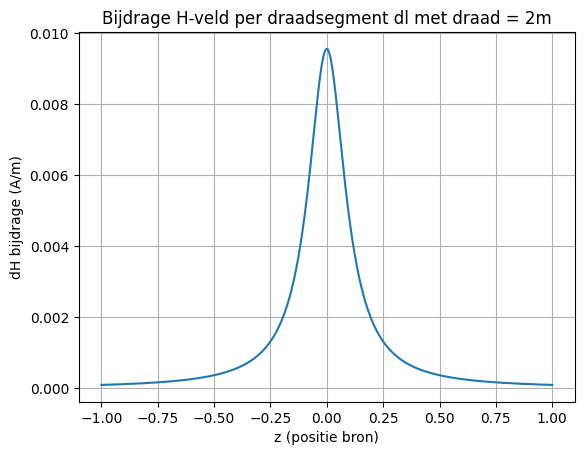

In [191]:

N = 1000 # aantal stukken

r_field = np.array([0.1, 0, 0]) #positie waar we het veld willen bepalen
r_source = np.array([0, 0, 0]) #positie van de bron

L_waarden = np.linspace(1,20,20)

for L in L_waarden:
    
    z = np.linspace(-L/2, L/2, N)
    dz = z[1] - z[0]
    dl = np.array([0, 0, dz])
    
    dH_list = []
    
    for zi in z:
        r_source = np.array([0, 0, zi])
        dH = field_current_element(r_field, r_source, dl)
        dH_list.append(dH)
    
    dH_array = np.array(dH_list)
    H_total = np.sum(dH_array, axis=0)
    analytical = I_bron_3 / (2 * np.pi * 0.1)
    print("Voor lengte L =", int(L), "m", " is het numerieke antwoord ", H_total[1], " en het analytische antwoord ", analytical)

         

z = np.linspace(-1,1,N)
dz = z[1] - z[0]
dl = np.array([0, 0, dz])
dH_list = []
for zi in z:
    r_source = np.array([0, 0, zi])
    dH = field_current_element(r_field, r_source, dl)
    dH_list.append(dH)
dH_array = np.array(dH_list)

plt.figure()
plt.plot(z, dH_array[:, 1])
plt.xlabel("z (positie bron)")
plt.ylabel("dH bijdrage (A/m)")
plt.title("Bijdrage H-veld per draadsegment dl met draad = 2m")
plt.grid()
plt.show()
    


### Deel 5: Numeriek berekenen van het magneetveld van een solenoide

We gaan nu het magneetveld van onze solenoide uitrekenen. Deze solenoide is een draad die om een cylinder gewikkeld is. Hieronder is een functie gegeven die de draad van een solenoide parametriseert. Deze parametrisatie gaan jullie gebruiken in combinatie met Biot-Savart om het H veld rond de solenoide te berekenen.

In [192]:
def parametrisatie(N,r_sol,aantal_omwentelingen,L_sol):
    t = np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen*t) # x coordinaten
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen*t) # y coordinaten
    z = L_sol* t - L_sol/2  # z componenten
    return x,y,z

**Opdracht 13**

Bereken het traject van een stroomdraad met een straal van $r_{sol}$. De solenoide met lengte $L_{sol}$ is gecentreerd op de oorsprong met de cilinderas langs de $z$-as. Doe dit door de hierboven gegeven functie te gebruiken.

a. Bereken het aantal omwentelingen van je draad, hierbij mag je aannemen dat de omtrek een cirkel is (in feite is het een ellips, maar omdat de windingen zo dicht op elkaar zitten is het vrijwel een cirkel).\
b. Bereken de $x$, $y$ en $z$ coordinaten.\
c. Bereken de spoed, in eenheden van aantal omwentelingen per meter, en print dit.

500
De spoel heeft 5000.0 omwentelingen per meter


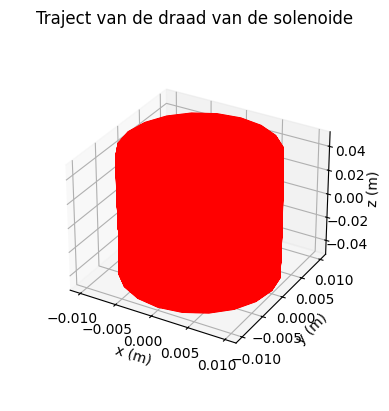

In [193]:
# Uit deur accutator:
l_draad = Max_lengte_draad_3_1           #m  # Lengte draad
r_sol_3_1 = 0.01 #Straal_spoel_3_1                            #m  # Straal solenoide
L_sol_3_1 = 0.1 #Lengte_spoel_3                          #m  # Lengte solenoide
I_bron_3 = 0.5 #Ampere
N_wendinge_spoel_3_1 = 500 #round(l_draad/(2*np.pi*r_sol_3_1)-1)    #   # Aantal wikkeling (afgerond)
print(N_wendinge_spoel_3_1)

N = 10000 

# parametrisatie toepassen
x,y,z = parametrisatie(N, r_sol_3_1, N_wendinge_spoel_3_1, L_sol_3_1)
# Enkele plots
ax=plt.figure().add_subplot(projection='3d')
plt.title('Traject van de draad van de solenoide')
plt.plot(x, y, z, '-r', linewidth=0.2)
ax.set_box_aspect(aspect=None, zoom=0.8)
ax.set_xlabel('x (m)'), ax.set_ylabel('y (m)'), ax.set_zlabel('z (m)')

# spoed berekenen
spoed_3_1 = N_wendinge_spoel_3_1/L_sol_3_1 # N/m

print(f"De spoel heeft {spoed_3_1} omwentelingen per meter")

Het veld in een oneindig lange solenoide wordt gegeven door $\mathbf{H} = n I \hat{\mathbf{z}}$, met $n$ de spoed van de draad, en $I$ de stroom.

**Opdracht 14**

Bereken het veld in het midden van de solenoide en vergelijk het met het analytische antwoord voor een oneindig lange solenoide. Verhoog $N$ net zo lang tot jullie antwoord convergeert naar het analytisch antwoord.
* Denk na over wat dl betekent en hoe jullie deze zou berekenen.
* Bereken met de functie die jullie eerder geschreven hebben de contributies aan het $H$-veld en sommeer deze.

In [194]:
###

## functies definieren
def line_element(x,y,z):
    dl_list = []
    for i in range(len(x)-1):
        dx = x[i]-x[i+1]
        dy = y[i]-y[i+1]
        dz = z[i]-z[i+1]
        l_element = [dx, dy, dz]
        dl_list.append(l_element)
    dl = np.array(dl_list)
    return dl

def r_source_step(x,y,z):
    r_source_list = []
    for i in range(len(x)-1):
        r_element = [x[i],y[i],z[i]]
        r_source_list.append(r_element)
    r_source = np.array(r_source_list)
    return r_source

def field_current_element_array(r_field, r_source, dl,I):
    dH_list = []
    for i in range(len(dl)):
        r_vec = r_field - r_source[i]
        r_mag = np.linalg.norm(r_vec)
        dH_element = I/(4*np.pi)*np.cross(dl[i], r_vec)/(r_mag**3)
        dH_list.append(dH_element) #uitproduct eenheidsvector met dl, en dan delen door verbindingsvecotr r^3 
    dH = np.array(dH_list)
    return dH

def theo_field(spoed, I):
    return spoed*I


## parameters definieren
r_field = np.array([0,0,0])

dl = line_element(x,y,z)

r_source = r_source_step(x,y,z)

#print(dl[0])
#print(r_source[0])

## dH berekenen:
dH_array = field_current_element_array(r_field, r_source, dl, I_bron_3)
#print(dH_array)


## H-veld berekenen:
H_theo = theo_field(spoed_3_1, I_bron_3)
H_num = np.linalg.norm(np.sum(dH_array, axis= 0))

print(f"Het H-veld in het midden van de solenoide is: H_theoretisch = {H_theo}")
print(f"Het H-veld in het midden van de solenoide is: H_nummeriek = {H_num}")
print(f"Het verschill is: {H_theo-H_num}")
print(f"De beste benadering van het nummerieke veld is met N = {N}")

###

Het H-veld in het midden van de solenoide is: H_theoretisch = 2500.0
Het H-veld in het midden van de solenoide is: H_nummeriek = 2411.3174839747276
Het verschill is: 88.68251602527243
De beste benadering van het nummerieke veld is met N = 10000


### Deel 6: Bereken krachtrespons van een kracht actuator
Omdat onze solenoide niet oneindig lang is zal het veld in de solenoide niet uniform zijn en ook niet op alle plaatsen exact langs de as gericht zijn.

**Opdracht 15**

Bereken de $z$-component van het $\mathbf{H}$-veld op de as van de solenoide over het interval $z \in [0, 1.5L_s]$ in 25 stappen. Je moet nu dus op elk veld-punt met behulp Biot-Savart de bijdragen van alle stroomelementen integreren. Maak een grafiek van de $z$-component van het $\mathbf{H}$-veld tegen $z$.

Ifield = 24

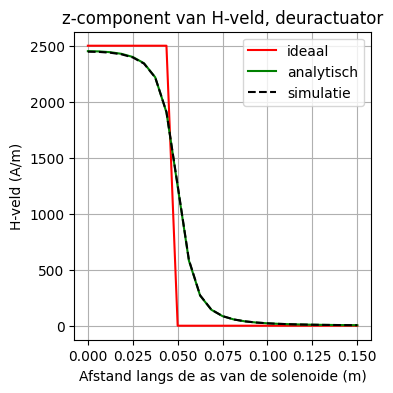

In [195]:
n_ax = 25
z_ax = np.linspace(0, 1.5*L_sol_3_1, n_ax)
H_ax = np.zeros((n_ax, 1))


# hoekverandering
n_phi = 100
phi_vals = np.linspace(0, 2*np.pi, n_phi)
dphi = 2*np.pi / n_phi


def field_current_element(r_field, r_source, dl, I):
    r_vec = r_field - r_source
    r_mag = np.linalg.norm(r_vec)
    return I/(4*np.pi)*np.cross(dl, r_vec)/(r_mag**3) #uitproduct eenheidsvector met dl, en dan delen door verbindingsvecotr r^3 



#numeriek berekend
for i_field in range(n_ax):
    print(f"\rIfield = {i_field}", end="")

    z = z_ax[i_field]
    r_field = np.array([0.0, 0.0, z])

    Hsimulated = np.array([0.0, 0.0, 0.0])

    for i_source in np.arange(N_wendinge_spoel_3_1):
        # positie van winding langs z
        z_source = -L_sol_3_1/2 + i_source * (L_sol_3_1 / (N_wendinge_spoel_3_1 - 1))

        for phi in phi_vals:
            # positie van stroomelement
            r_source = np.array([r_sol_3_1 * np.cos(phi), r_sol_3_1 * np.sin(phi), z_source])

            # differentieel element dl
            dl = np.array([-r_sol_3_1 * np.sin(phi), r_sol_3_1 * np.cos(phi), 0.0]) * dphi

            #delen bij elkaar optellen
            Hsimulated += field_current_element(r_field, r_source, dl, I_bron_3)
    
    #totaal H-veld:
    H_ax[i_field, 0] = Hsimulated[2]



# ideaal geval
analytisch_antwoord = (spoed_3_1 * I_bron_3)# / L_sol_3_1
H_veld_ideaal = analytisch_antwoord * np.ones(n_ax) * (z_ax < L_sol_3_1/2)


# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_veld_analytisch=(N_wendinge_spoel_3_1*I_bron_3/L_sol_3_1/2)*((L_sol_3_1/2-z_ax)/np.sqrt((z_ax- L_sol_3_1/2)**2 + r_sol_3_1**2)+(L_sol_3_1/2+z_ax)/np.sqrt((z_ax+ L_sol_3_1/2)**2 + r_sol_3_1**2))

#plot
plt.figure(figsize=(13,4))
plt.subplot(131)
plt.title('z-component van H-veld, deuractuator')
plt.plot(z_ax, H_veld_ideaal, '-r', label='ideaal')
plt.plot(z_ax, H_veld_analytisch, '-g', label='analytisch')
plt.plot(z_ax, H_ax, '--k', label='simulatie')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('H-veld (A/m)')

plt.legend()
plt.grid()

plt.show()

We gaan de solenoide nu gebruiken voor onze krachtactuator. Daarvoor gaan we opnieuw de energie in het magnetisch veld berekenen, maar nu met het numerieke resultaat voor een eindige lengte solenoide. We gaan hier nu een aantal aannames maken:
* We nemen aan het veld alleen een $z$-component heeft en niet afhangt van de afstand tot de solenoide as
* We verwaarlozen de bijdrage aan de energie van het deel van de solenoide gevuld in lucht en integreren alleen het deel van ijzer in het $\mathbf{H}$ veld (dat mag omdat $\mu_r \gg 1$)
* De plunjer is oneindig lang

Zoals je uit je berekening voor het $\mathbf{H}$ kan zien is de energie van de plunjer in de solenoide groter dan voor de plunjer uit de solenoide. Dit komt doordat we de berekening doen met constante stroom. De verplaatsing van de plunjer geeft echter ook een veranderende flux ($d \Phi/dt$) die een tegen EMF geeft. Deze moet overwonnen worden door de stroombron die de arbeid levert. Het magneetveld verricht dus geen arbeid, dat doet de stroombron! We berekenen dit effect hier niet expliciet, maar nemen $-W$ als energie zodat de kracht de juiste kant op wijst (de solenoide in, dus een kracht in de $-z$ richting).


**Opdracht 16**

* Bereken de energie als functie van de afstand van de plunjer in de solenoide met behulp van onderstaand script

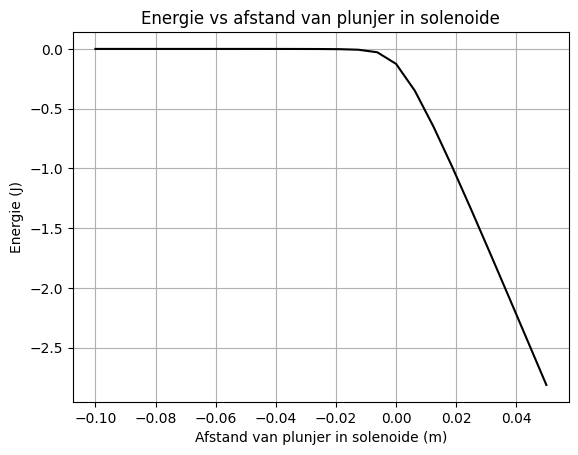

In [196]:
# integrate the field up to point z_p
Wz=-0.5*np.pi*r_sol_3_1**2*np.cumsum(np.flipud(H_ax)*mu_r_plunjer_3_1*mu_0*np.flipud(H_ax))*(z_ax[1] - z_ax[0])

plt.plot(L_sol_3_1/2 - z_ax, np.flipud(Wz), '-k')
plt.title('Energie vs afstand van plunjer in solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)')
plt.ylabel('Energie (J)')
plt.grid()

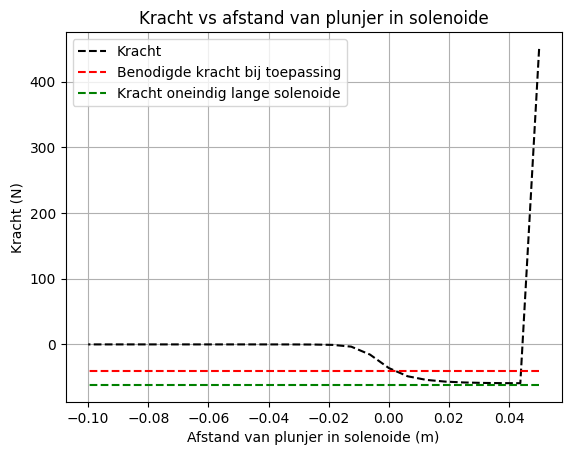

In [197]:
force_analytical1 = -mu_0*mu_r_plunjer_3_1*np.pi*r_sol_3_1**2*N_wendinge_spoel_3_1**2*I_bron_3**2/2/L_sol_3_1**2 # Kracht uitrekenen numeriek
force_analytical2 = -F_plunjer(N_wendinge_spoel_3_1, Straal_spoel_3_1, L_sol_3_1, mu_r_plunjer_3_1, I_bron_3) #hetzelfde verhaal, alleen met de functie
force_numerical=np.diff(Wz, n=1, append=[0])/(z_ax[1] - z_ax[0]) # Kracht uitrekenen


# Plotting the results
plt.figure()
plt.title('Kracht vs afstand van plunjer in solenoide')
plt.plot(L_sol_3_1/2 - z_ax, np.flipud(force_numerical), '--k', label='Kracht')
plt.plot(L_sol_3_1/2 - z_ax, -F_min_3*np.ones(n_ax), '--r', label='Benodigde kracht bij toepassing')
plt.plot(L_sol_3_1/2 - z_ax, force_analytical1*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
#plt.ylim([-100, 20])
plt.show()

### Deel 7: Beoordeling van de criteria
**Opdracht 17**

Kijk in deze vraag terug naar de criteria die jullie voor de deuractuator hebben opgesteld. Voldoet jullie ontwerp aan alle gestelde criteria?


Plaats hier jullie evaluatie of de deur actuator aan de minimale kracht eis voldoet

Kwa straal van de spoel en lengte van de spoel, 1.6 cm en 5 cm, voldoet ons ontwerp aan de criteria.

**Opdracht 18**

Voer opdrachten 15 en 16 uit voor jouw eigen gekozen toepassingen.

Ifield = 24

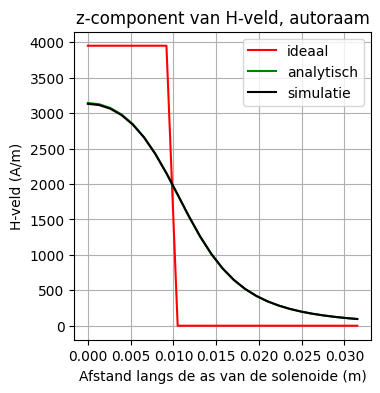

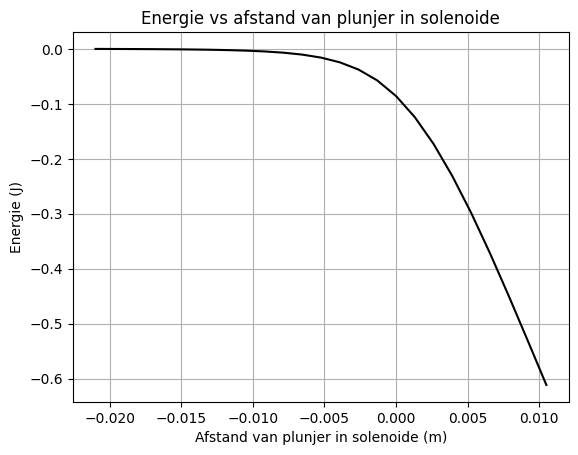

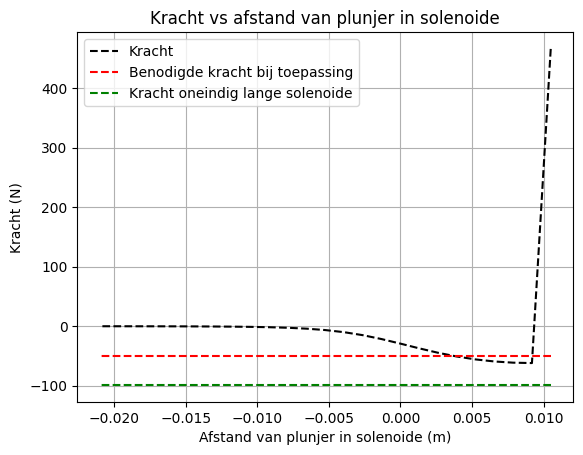

In [198]:
#opdracht 15 voor toepassing 1:
l_draad = Max_lengte_draad_1_1         #m  # Lengte draad
r_sol_1_1 = Straal_spoel_1_1                            #m  # Straal solenoide
L_sol_1_1 = Lengte_spoel_1                          #m  # Lengte solenoide
I_bron_1 = 0.5 #Ampere
N_wendinge_spoel_1_1 = round(l_draad/(2*np.pi*r_sol_1_1)-1)    #   # Aantal wikkeling (afgerond)

n_ax = 25
z_ax = np.linspace(0, 1.5*L_sol_1_1, n_ax)
H_ax = np.zeros((n_ax, 1))

# hoekverandering
n_phi = 100
phi_vals = np.linspace(0, 2*np.pi, n_phi)
dphi = 2*np.pi / n_phi


def field_current_element(r_field, r_source, dl, I):
    r_vec = r_field - r_source
    r_mag = np.linalg.norm(r_vec)
    return I/(4*np.pi)*np.cross(dl, r_vec)/(r_mag**3) #uitproduct eenheidsvector met dl, en dan delen door verbindingsvecotr r^3 



#numeriek berekend
for i_field in range(n_ax):
    print(f"\rIfield = {i_field}", end="")

    z = z_ax[i_field]
    r_field = np.array([0.0, 0.0, z])

    Hsimulated = np.array([0.0, 0.0, 0.0])

    for i_source in np.arange(N_wendinge_spoel_1_1):
        # positie van winding langs z
        z_source = -L_sol_1_1/2 + i_source * (L_sol_1_1 / (N_wendinge_spoel_1_1 - 1))

        for phi in phi_vals:
            # positie van stroomelement
            r_source = np.array([r_sol_1_1 * np.cos(phi), r_sol_1_1 * np.sin(phi), z_source])

            # differentieel element dl
            dl = np.array([-r_sol_1_1 * np.sin(phi), r_sol_1_1 * np.cos(phi), 0.0]) * dphi

            #delen bij elkaar optellen
            Hsimulated += field_current_element(r_field, r_source, dl, I_bron_1)
    
    #totaal H-veld:
    H_ax[i_field, 0] = Hsimulated[2]

# ideaal geval
analytisch_antwoord = (N_wendinge_spoel_1_1 * I_bron_1) / L_sol_1_1
H_veld_ideaal = analytisch_antwoord * np.ones(n_ax) * (z_ax < L_sol_1_1/2)


# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_veld_analytisch=(N_wendinge_spoel_1_1*I_bron_1/L_sol_1_1/2)*((L_sol_1_1/2-z_ax)/np.sqrt((z_ax- L_sol_1_1/2)**2 + r_sol_1_1**2)+(L_sol_1_1/2+z_ax)/np.sqrt((z_ax+ L_sol_1_1/2)**2 + r_sol_1_1**2))

#plot
plt.figure(figsize=(13,4))
plt.subplot(131)
plt.title('z-component van H-veld, autoraam')
plt.plot(z_ax, H_veld_ideaal, '-r', label='ideaal')
plt.plot(z_ax, H_veld_analytisch, '-g', label='analytisch')
plt.plot(z_ax, H_ax, '-k', label='simulatie')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('H-veld (A/m)')

plt.legend()
plt.grid()
plt.show()

#opdracht 16 voor toepassing 1:

# integrate the field up to point z_p
Wz=-0.5*np.pi*r_sol_1_1**2*np.cumsum(np.flipud(H_ax)*mu_r_plunjer_1_1*mu_0*np.flipud(H_ax))*(z_ax[1] - z_ax[0])

plt.plot(L_sol_1_1/2 - z_ax, np.flipud(Wz), '-k')
plt.title('Energie vs afstand van plunjer in solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)')
plt.ylabel('Energie (J)')
plt.grid()

force_analytical = -mu_0*mu_r_plunjer_1_1*np.pi*r_sol_1_1**2*N_wendinge_spoel_1_1**2*I_bron_1**2/2/L_sol_1_1**2 # Kracht uitrekenen numeriek
force_analytical = -F_plunjer(N_wendinge_spoel_1_1, Straal_spoel_1_1, L_sol_1_1, mu_r_plunjer_1_1, I_bron_1)
force_numerical=np.diff(Wz, n=1, append=[0])/(z_ax[1] - z_ax[0]) # Kracht uitrekenen



# Plotting the results
plt.figure()
plt.title('Kracht vs afstand van plunjer in solenoide')
plt.plot(L_sol_1_1/2 - z_ax, np.flipud(force_numerical), '--k', label='Kracht')
plt.plot(L_sol_1_1/2 - z_ax, -F_min_1*np.ones(n_ax), '--r', label='Benodigde kracht bij toepassing')
plt.plot(L_sol_1_1/2 - z_ax, force_analytical*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)'), plt.ylabel('Kracht (N)'), plt.grid(), plt.legend()
#plt.ylim([-1, 0])
plt.show()

Ifield = 24

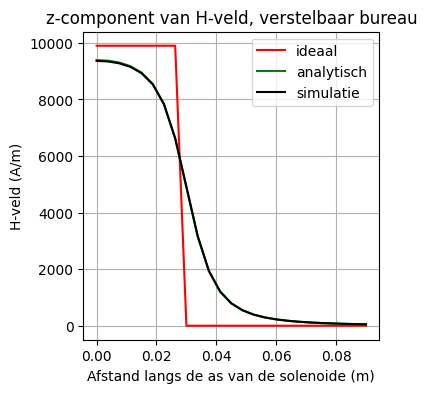

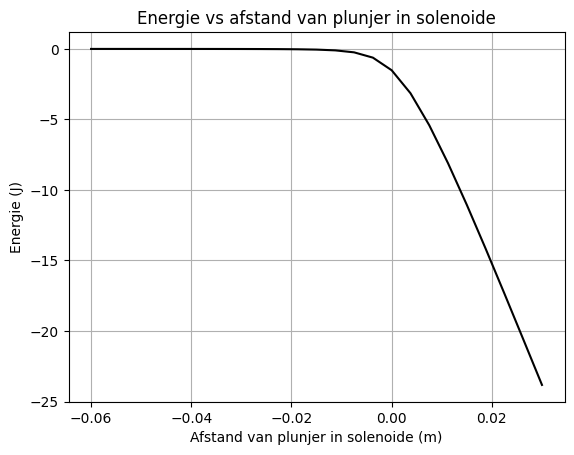

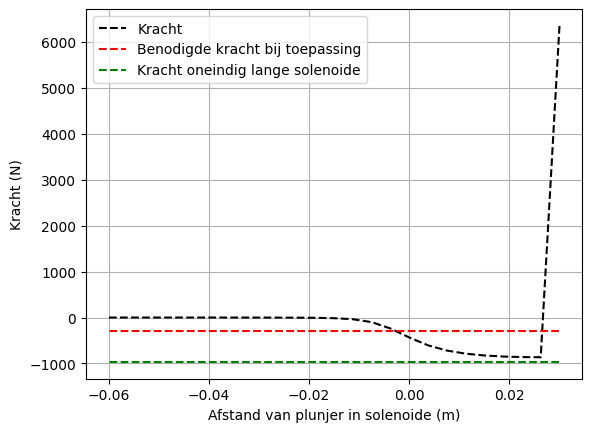

In [199]:
#opdracht 15 voor toepassing 2:
l_draad = Max_lengte_draad_2_1              #m  # Lengte draad
r_sol_2_1 = Straal_spoel_2_1                            #m  # Straal solenoide
L_sol_2_1 = Lengte_spoel_2                        #m  # Lengte solenoide
I_bron_2 = 2 #Ampere
N_wendinge_spoel_2_1 = round(l_draad/(2*np.pi*r_sol_2_1)-1)    #   # Aantal wikkeling (afgerond)

n_ax = 25
z_ax = np.linspace(0, 1.5*L_sol_2_1, n_ax)
H_ax = np.zeros((n_ax, 1))

# hoekverandering
n_phi = 100
phi_vals = np.linspace(0, 2*np.pi, n_phi)
dphi = 2*np.pi / n_phi


def field_current_element(r_field, r_source, dl, I):
    r_vec = r_field - r_source
    r_mag = np.linalg.norm(r_vec)
    return I/(4*np.pi)*np.cross(dl, r_vec)/(r_mag**3) #uitproduct eenheidsvector met dl, en dan delen door verbindingsvecotr r^3 



#numeriek berekend
for i_field in range(n_ax):
    print(f"\rIfield = {i_field}", end="")

    z = z_ax[i_field]
    r_field = np.array([0.0, 0.0, z])

    Hsimulated = np.array([0.0, 0.0, 0.0])

    for i_source in np.arange(N_wendinge_spoel_2_1):
        # positie van winding langs z
        z_source = -L_sol_2_1/2 + i_source * (L_sol_2_1 / (N_wendinge_spoel_2_1 - 1))

        for phi in phi_vals:
            # positie van stroomelement
            r_source = np.array([r_sol_2_1 * np.cos(phi), r_sol_2_1 * np.sin(phi), z_source])

            # differentieel element dl
            dl = np.array([-r_sol_2_1 * np.sin(phi), r_sol_2_1 * np.cos(phi), 0.0]) * dphi

            #delen bij elkaar optellen
            Hsimulated += field_current_element(r_field, r_source, dl, I_bron_2)
    
    #totaal H-veld:
    H_ax[i_field, 0] = Hsimulated[2]

# ideaal geval
analytisch_antwoord = (N_wendinge_spoel_2_1 * I_bron_2) / L_sol_2_1
H_veld_ideaal = analytisch_antwoord * np.ones(n_ax) * (z_ax < L_sol_2_1/2)


# dit is nog een aardige analytische uitdrukking die je kan uitrekenen voor de z-component op de as van een solenoide met eindige lengte
H_veld_analytisch=(N_wendinge_spoel_2_1*I_bron_2/L_sol_2_1/2)*((L_sol_2_1/2-z_ax)/np.sqrt((z_ax- L_sol_2_1/2)**2 + r_sol_2_1**2)+(L_sol_2_1/2+z_ax)/np.sqrt((z_ax+ L_sol_2_1/2)**2 + r_sol_2_1**2))

#plot
plt.figure(figsize=(13,4))
plt.subplot(131)
plt.title('z-component van H-veld, verstelbaar bureau')
plt.plot(z_ax, H_veld_ideaal, '-r', label='ideaal')
plt.plot(z_ax, H_veld_analytisch, '-g', label='analytisch')
plt.plot(z_ax, H_ax, '-k', label='simulatie')
plt.xlabel('Afstand langs de as van de solenoide (m)')
plt.ylabel('H-veld (A/m)')

plt.legend()
plt.grid()
plt.show()

#opdracht 16 voor toepassing 2:

# integrate the field up to point z_p
Wz=-0.5*np.pi*r_sol_2_1**2*np.cumsum(np.flipud(H_ax)*mu_r_plunjer_2_1*mu_0*np.flipud(H_ax))*(z_ax[1] - z_ax[0])

plt.plot(L_sol_2_1/2 - z_ax, np.flipud(Wz), '-k')
plt.title('Energie vs afstand van plunjer in solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)')
plt.ylabel('Energie (J)')
plt.grid()
force_analytical = -mu_0*mu_r_plunjer_2_1*np.pi*r_sol_2_1**2*N_wendinge_spoel_2_1**2*I_bron_2**2/2/L_sol_2_1**2 # Kracht uitrekenen numeriek
force_analytical = -F_plunjer(N_wendinge_spoel_2_1, Straal_spoel_2_1, L_sol_2_1, mu_r_plunjer_2_1, I_bron_2)
force_numerical=np.diff(Wz, n=1, append=[0])/(z_ax[1] - z_ax[0]) # Kracht uitrekenen


# Plotting the results
plt.figure()
plt.plot(L_sol_2_1/2 - z_ax, np.flipud(force_numerical), '--k', label='Kracht')
plt.plot(L_sol_2_1/2 - z_ax, -F_min_2*np.ones(n_ax), '--r', label='Benodigde kracht bij toepassing')
plt.plot(L_sol_2_1/2 - z_ax, force_analytical*np.ones(n_ax), '--g', label='Kracht oneindig lange solenoide')
plt.xlabel('Afstand van plunjer in solenoide (m)')
plt.ylabel('Kracht (N)')
plt.grid()
plt.legend()
#plt.ylim([-1, 0])
plt.show()

**Opdracht 19**

a. Kijk terug naar de criteria die jullie hebben opgesteld in vraag 5. Hebben jullie nu genoeg informatie om te beoordelen of jullie ontwerp voldoet aan de gestelde criteria, zo nee ontwerp een simpel experiment waarmee jullie het wel zouden uit kunnen voeren.
b. Beoordeel op basis van de criteria die jullie wel kunnen beoordelen of jullie idee voldoet aan jullie criteria.

Edit deze cel met jullie antwoorden op vraag 19.

Autoraam:
Onder de gegeven voorwaarden (spanningsbron en stroomsterkte, draaddikte en straal van de spoel, en de minimale kracht), voldoet onze gesimuleerde solenoïde aan de eisen voor de toepassing.

Bureautafel:
Onder de gegeven voorwaarden (spanningsbron en stroomsterkte, draaddikte en straal van de spoel, en de minimale kracht), voldoet onze gesimuleerde solenoïde aan de eisen voor de toepassing. Wel moest er een andere spanningsbron gebruikt worden, (de 20V telefoonoplader), i.p.v. de 9V batterij om de benodigde kracht voor onze toepassing te behalen.

Deuractuator:
Onder de gegeven voorwaarden (spanningsbron en stroomsterkte, draaddikte en straal van de spoel, en de minimale kracht), voldoet onze gesimuleerde solenoïde aan de eisen voor de toepassing. Onze grafiek ziet er echt heel mooi uit!

Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.